# Exploratory Data Analysis (EDA)
This notebook analyzes the transaction dataset to find correlations, distributions, and patterns. We check for missing values, duplicates, and outline the general financial profile.

In [3]:
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 463 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('../model/data/Personal_Finance_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f"Dataset Shape: {df.shape}")
print(f"Missing Values:\n{df.isnull().sum()}\n")
print(f"Duplicate Rows: {df.duplicated().sum()}")
df.head()

Dataset Shape: (1500, 5)
Missing Values:
Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64

Duplicate Rows: 0


,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


## 1. Monthly Expense Trend

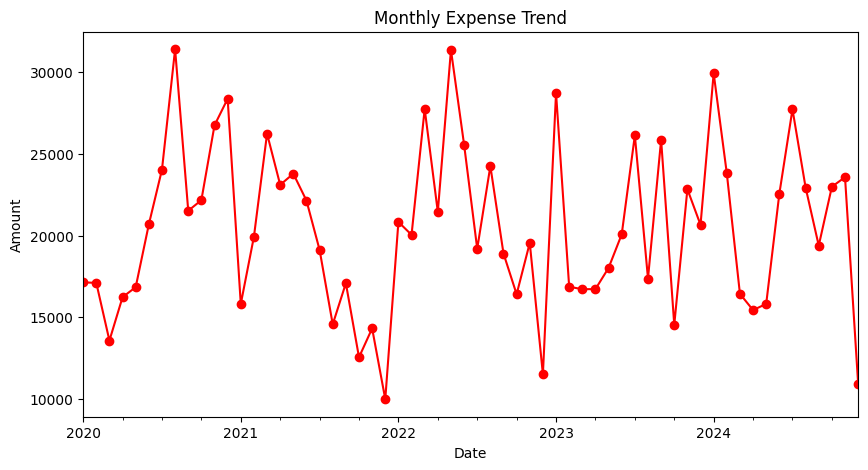

In [5]:
expenses = df[df['Type'].str.lower() == 'expense']
monthly_expenses = expenses.resample('ME', on='Date')['Amount'].sum()
plt.figure(figsize=(10,5))
monthly_expenses.plot(kind='line', marker='o', color='red')
plt.title('Monthly Expense Trend')
plt.ylabel('Amount')
plt.show()

## 2. Category Distribution & Outliers

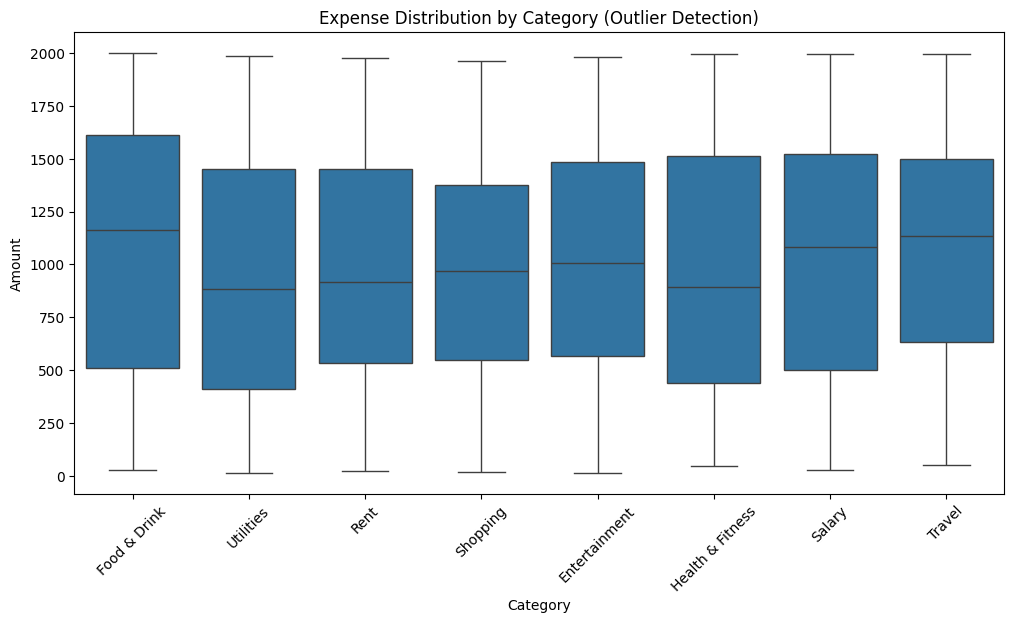

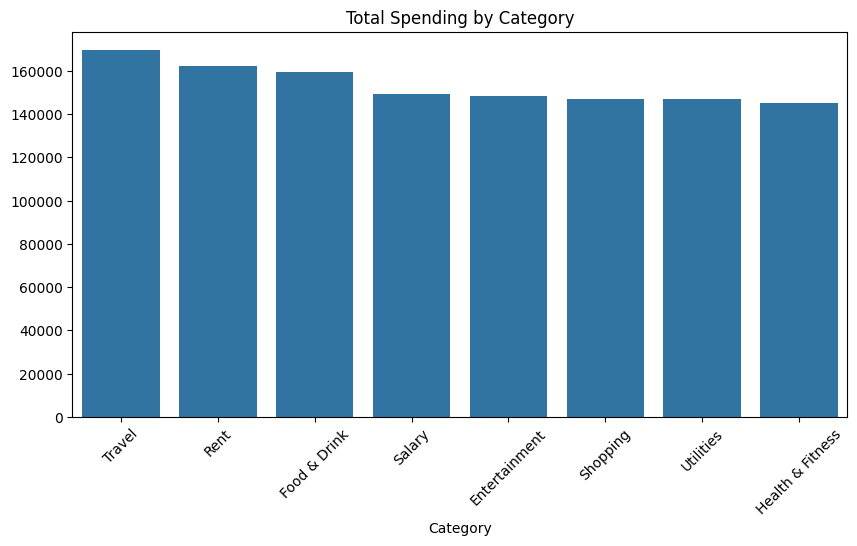

In [6]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='Amount', data=expenses)
plt.title('Expense Distribution by Category (Outlier Detection)')
plt.xticks(rotation=45)
plt.show()

cat_sum = expenses.groupby('Category')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=cat_sum.index, y=cat_sum.values)
plt.title('Total Spending by Category')
plt.xticks(rotation=45)
plt.show()

## 3. Savings Trend (Income vs Expense)

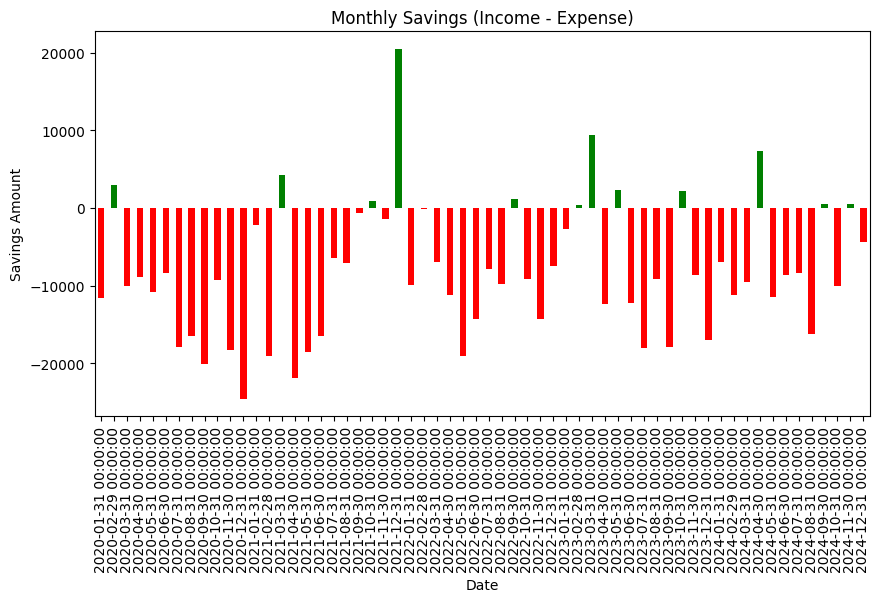

In [7]:
income = df[df['Type'].str.lower() == 'income'].resample('ME', on='Date')['Amount'].sum()
savings = income - monthly_expenses
plt.figure(figsize=(10,5))
savings.plot(kind='bar', color=savings.apply(lambda x: 'green' if x > 0 else 'red'))
plt.title('Monthly Savings (Income - Expense)')
plt.ylabel('Savings Amount')
plt.show()

## 4. Correlation Matrix (Monthly Features)

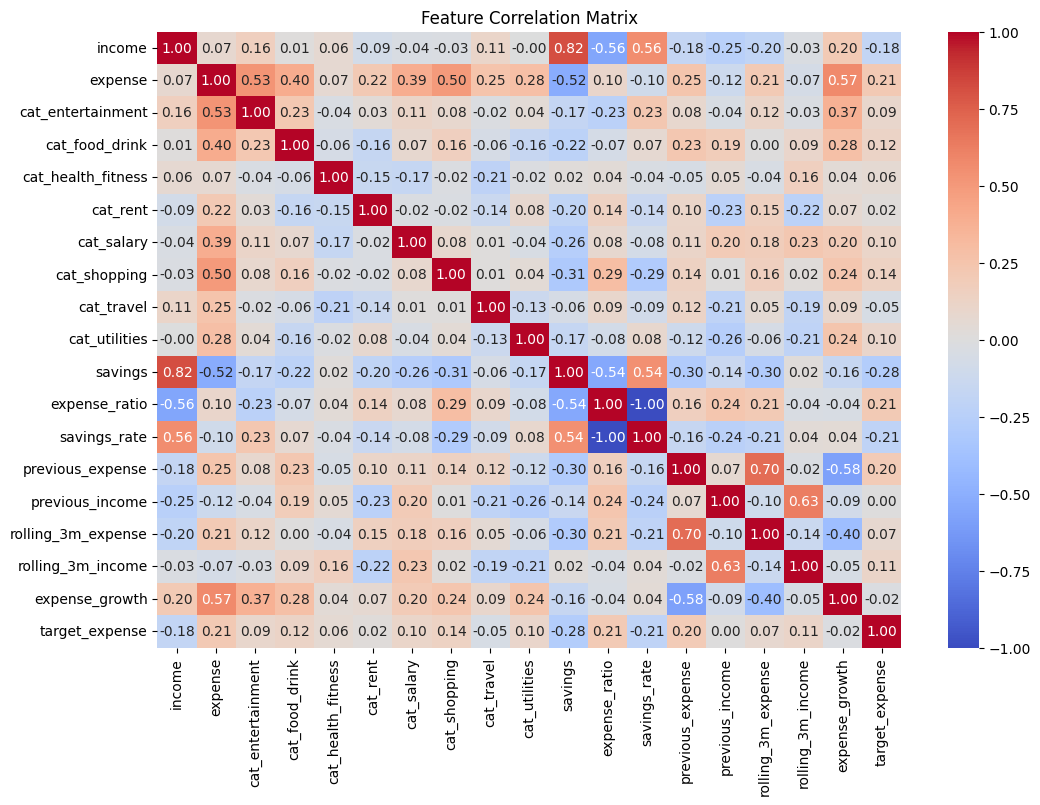

In [8]:
features_df = pd.read_csv('../model/data/monthly_features.csv')
plt.figure(figsize=(12,8))
sns.heatmap(features_df.drop(['year_month'], axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()